# Yelp Review Prediction - 30D1Y COVID (Template Import)

This notebook imports functions from `prediction_template.ipynb` and runs the full pipeline with COVID settings.

In [1]:
from pathlib import Path

%run ./prediction_template.ipynb

PROCESSED_DIR = Path("./processed_data")
COHORT_YEAR = 2020 
EARLY_WINDOW_DAYS = 30 * 3
FUTURE_WINDOW_END_DAY = 365
MIN_EARLY_REVIEWS = 5
MIN_FUTURE_REVIEWS = 15
PERIOD = "COVID"
FEATURE_FILE = "review_features.csv"

Sanity check report
Rows: 681
Columns: 16
Features: 14
Missing features: 0
Duplicate business_id: 0
Missing target values: 0
Missing feature values: 0
Target summary:
count    681.000000
mean       4.147741
std        0.648553
min        1.000000
25%        3.862500
50%        4.309524
75%        4.600000
max        5.000000
dtype: float64
Regression results
               model       mae      rmse        r2  n_train  n_test  \
0  linear_regression  0.332300  0.450798  0.469350      544     137   
1              ridge  0.332512  0.450027  0.471164      544     137   
2      random_forest  0.347369  0.463961  0.437908      544     137   
3            xgboost  0.358442  0.474293  0.412595      544     137   
4      baseline_mean  0.483452  0.618987 -0.000476      544     137   

   n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used  
0          14     0.328188    0.021159    0.524955   0.088600              5  
1          14     0.328000    0.020571    0.526166   0

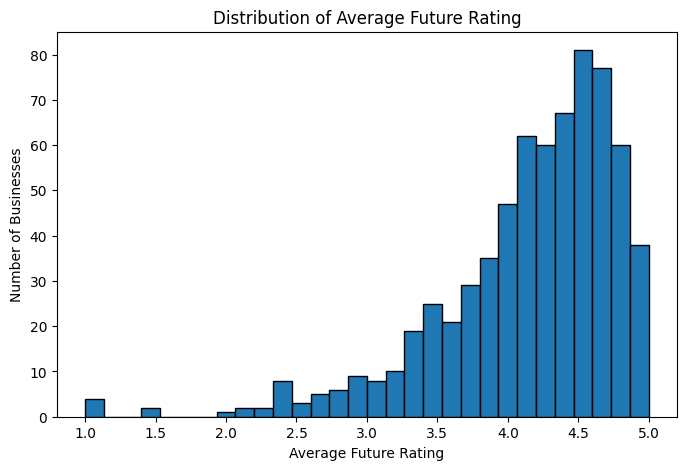

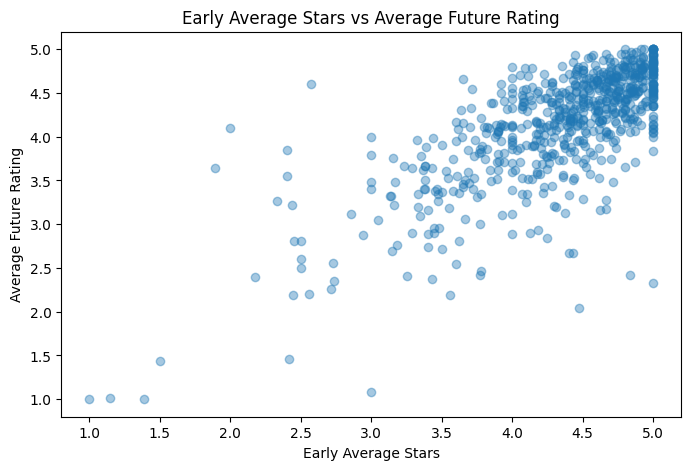

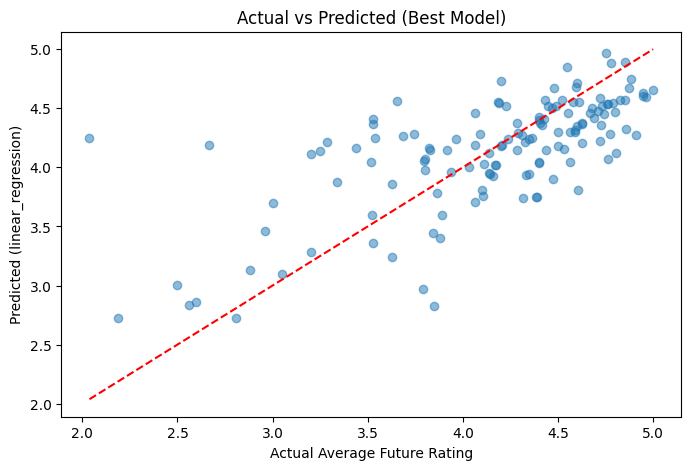

Best model: linear_regression
model            linear_regression
mae                         0.3323
rmse                      0.450798
r2                         0.46935
n_train                        544
n_test                         137
n_features                      14
cv_mae_mean               0.328188
cv_mae_std                0.021159
cv_r2_mean                0.524955
cv_r2_std                   0.0886
cv_folds_used                    5
Name: 0, dtype: object


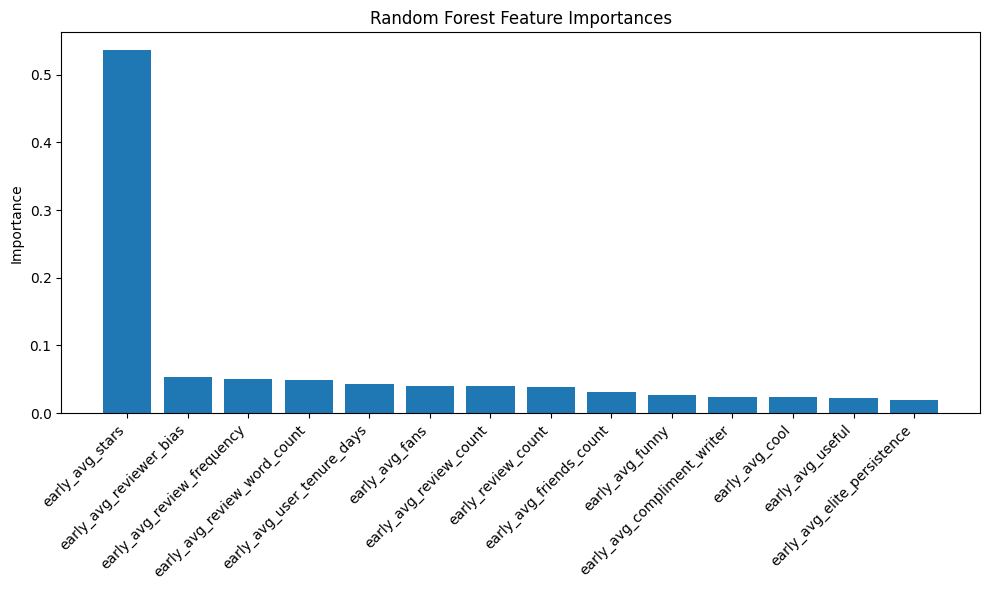

Top correlations with average_future_rating:


,feature,corr
0,early_avg_stars,0.726866
1,early_avg_reviewer_bias,0.614039
2,early_avg_review_word_count,-0.214248
3,early_avg_user_tenure_days,0.139195
4,early_avg_cool,0.125329
5,early_avg_fans,0.120640
6,early_avg_friends_count,0.105499
7,early_avg_elite_persistence,0.097884
8,early_avg_review_count,0.095658
9,early_avg_review_frequency,0.074375


,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
1,-1YvpVvnnLrTZ0zjtUYPXA,3.437500,2.781250,0.125000,0.656250,72.062500,3.156250,140.468750,3.375000,-0.291875,2081.156250,1.218750,120.125000,32.562500,32,3.985294
7,-2wh7NTLkWEgsrLJvilnFQ,4.705882,2.117647,0.352941,1.352941,208.764706,23.294118,77.764706,17.588235,0.547647,2173.000000,0.529412,74.941176,70.176471,17,4.318182
8,-3-6BB10tIWNKGEF0Es2BA,3.861111,2.500000,0.527778,0.972222,46.472222,3.611111,60.527778,2.055556,0.018611,1711.861111,1.083333,123.333333,23.500000,36,4.382716
17,-BdYhP-12elmFV7oB1iv4A,5.000000,0.750000,0.125000,0.500000,41.125000,3.000000,79.750000,1.125000,0.560000,2106.625000,0.875000,78.250000,5.250000,8,4.818182
24,-FPHImCrh555pkxNetpreA,4.588235,1.941176,0.117647,1.000000,157.705882,15.000000,163.176471,15.235294,0.359412,1694.529412,1.764706,137.294118,62.294118,17,4.305556


In [2]:
pipeline_output = run_prediction_pipeline(
    processed_dir=PROCESSED_DIR,
    cohort_year=COHORT_YEAR,
    early_window_days=EARLY_WINDOW_DAYS,
    future_window_end_day=FUTURE_WINDOW_END_DAY,
    period=PERIOD,
    min_early_reviews=MIN_EARLY_REVIEWS,
    min_future_reviews=MIN_FUTURE_REVIEWS,
    feature_file=FEATURE_FILE,
)

model_df = pipeline_output["model_df"]
feature_cols = pipeline_output["feature_cols"]
target_col = pipeline_output["target_col"]

print("Model dataset shape:", model_df.shape)
print("Target column:", target_col)
print("Number of features:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])
print("Sanity report:", pipeline_output["sanity_report"])
print("Regression summary:")
print(pipeline_output["regression_report"]["results_df"])

output_dir = PROCESSED_DIR / "modeling_tables"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"business_level_{EARLY_WINDOW_DAYS}D_{FUTURE_WINDOW_END_DAY}D_{PERIOD}.csv"
model_df.to_csv(output_path, index=False, float_format="%.4f")
print("Saved modeling table to:", output_path.resolve())

results_package = generate_results_package(
    pipeline_output=pipeline_output,
    target_col=target_col,
    top_n_correlations=15,
    show_plots=True,
)

print("Top correlations with average_future_rating:")
display(results_package["correlation_table"])

model_df.head()

In [3]:
# Exploratory Tables and Graphs
# Summary stats, head, and missing values
import pandas as pd

print("Model dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nSummary statistics:")
print(model_df.describe())

print("\nMissing values per column:")
print(model_df.isnull().sum())

print("\nFirst 5 rows:")
model_df.head()

Model dataset shape: (681, 16)

Columns:
['business_id', 'early_avg_stars', 'early_avg_useful', 'early_avg_funny', 'early_avg_cool', 'early_avg_review_count', 'early_avg_fans', 'early_avg_friends_count', 'early_avg_compliment_writer', 'early_avg_reviewer_bias', 'early_avg_user_tenure_days', 'early_avg_elite_persistence', 'early_avg_review_word_count', 'early_avg_review_frequency', 'early_review_count', 'average_future_rating']

Summary statistics:
       early_avg_stars  early_avg_useful  early_avg_funny  early_avg_cool  \
count       681.000000        681.000000       681.000000      681.000000   
mean          4.336756          1.658946         0.385313        0.943125   
std           0.624150          1.475962         0.642627        1.233772   
min           1.000000          0.000000         0.000000        0.000000   
25%           4.066667          0.850000         0.083333        0.266667   
50%           4.500000          1.312500         0.227273        0.625000   
75%      

,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
1,-1YvpVvnnLrTZ0zjtUYPXA,3.437500,2.781250,0.125000,0.656250,72.062500,3.156250,140.468750,3.375000,-0.291875,2081.156250,1.218750,120.125000,32.562500,32,3.985294
7,-2wh7NTLkWEgsrLJvilnFQ,4.705882,2.117647,0.352941,1.352941,208.764706,23.294118,77.764706,17.588235,0.547647,2173.000000,0.529412,74.941176,70.176471,17,4.318182
8,-3-6BB10tIWNKGEF0Es2BA,3.861111,2.500000,0.527778,0.972222,46.472222,3.611111,60.527778,2.055556,0.018611,1711.861111,1.083333,123.333333,23.500000,36,4.382716
17,-BdYhP-12elmFV7oB1iv4A,5.000000,0.750000,0.125000,0.500000,41.125000,3.000000,79.750000,1.125000,0.560000,2106.625000,0.875000,78.250000,5.250000,8,4.818182
24,-FPHImCrh555pkxNetpreA,4.588235,1.941176,0.117647,1.000000,157.705882,15.000000,163.176471,15.235294,0.359412,1694.529412,1.764706,137.294118,62.294118,17,4.305556


In [4]:
# Correlation with target: top features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if "average_future_rating" in numeric_cols:
    corr_series = model_df[numeric_cols].corr()["average_future_rating"].drop("average_future_rating")
    corr_top = corr_series.abs().sort_values(ascending=False).head(15)
    print("Top correlations with average_future_rating (by absolute value):")
    display(pd.DataFrame({"feature": corr_top.index, "corr": corr_top.values}))
else:
    print("average_future_rating not in numeric columns; skipping correlation summary.")

Top correlations with average_future_rating (by absolute value):


,feature,corr
0,early_avg_stars,0.726866
1,early_avg_reviewer_bias,0.614039
2,early_avg_review_word_count,0.214248
3,early_avg_user_tenure_days,0.139195
4,early_avg_cool,0.125329
5,early_avg_fans,0.120640
6,early_avg_friends_count,0.105499
7,early_avg_elite_persistence,0.097884
8,early_avg_review_count,0.095658
9,early_avg_review_frequency,0.074375


ALL MODEL RESULTS
               model       mae      rmse        r2  n_train  n_test  n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used
0  linear_regression  0.332300  0.450798  0.469350      544     137          14     0.328188    0.021159    0.524955   0.088600              5
1              ridge  0.332512  0.450027  0.471164      544     137          14     0.328000    0.020571    0.526166   0.086017              5
2      random_forest  0.347369  0.463961  0.437908      544     137          14     0.343136    0.012073    0.456996   0.076354              5
3            xgboost  0.358442  0.474293  0.412595      544     137          14     0.355547    0.012050    0.403654   0.088705              5
4      baseline_mean  0.483452  0.618987 -0.000476      544     137          14     0.486360    0.017628   -0.006863   0.005877              5



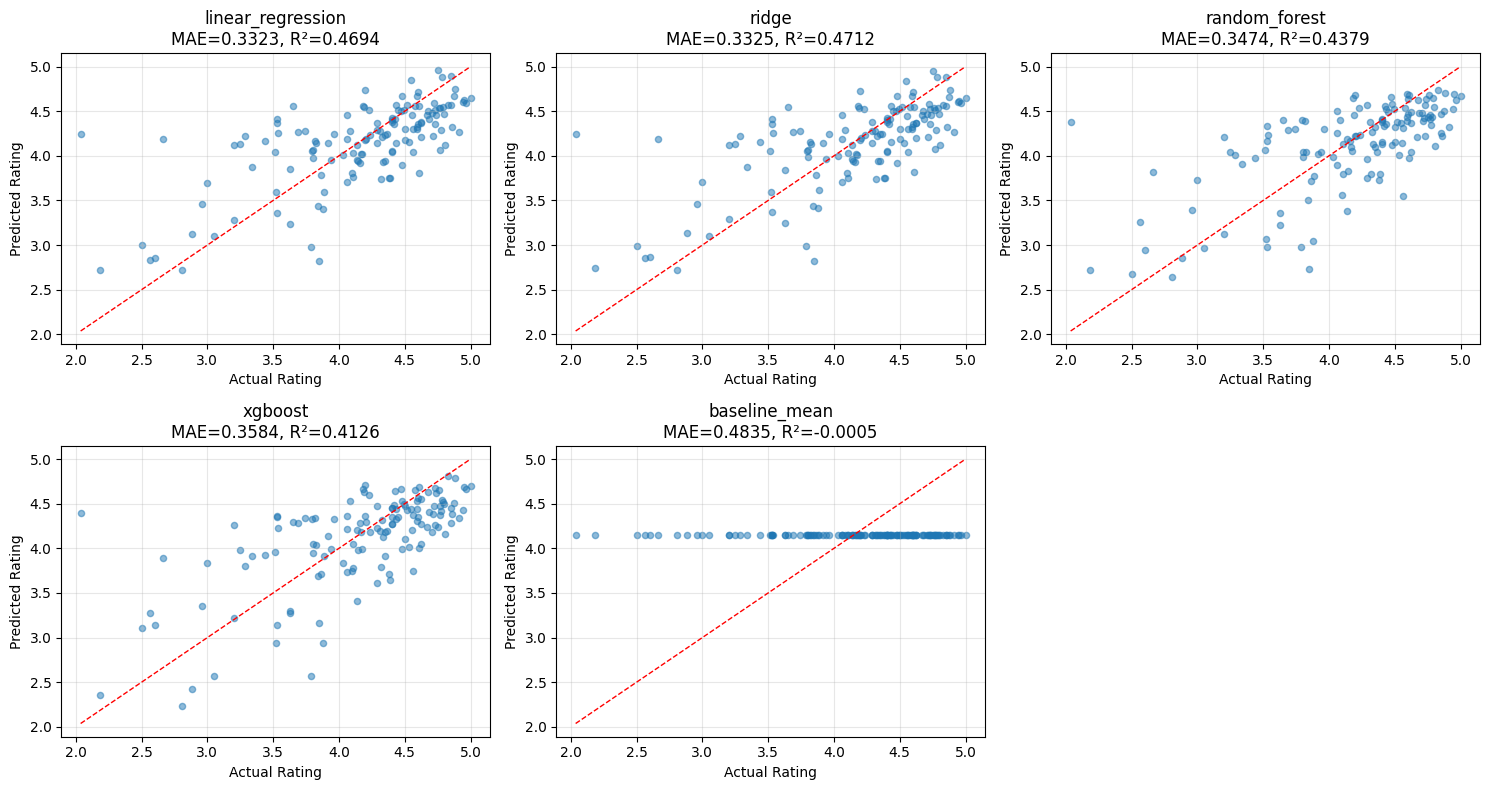

In [5]:
# Model Results: All models with predicted vs actual plots
import numpy as np

results_df = pipeline_output["regression_report"]["results_df"]
predictions_df = pipeline_output["regression_report"]["predictions_df"].copy()

print("=" * 80)
print("ALL MODEL RESULTS")
print("=" * 80)
print(results_df.to_string())
print()

y_true = predictions_df["average_future_rating"].values
min_val = float(y_true.min())
max_val = float(y_true.max())

# Plot predicted vs actual for each model
num_models = len(results_df)
n_cols = 3
n_rows = (num_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to 1D array for easier iteration

for idx, (_, row) in enumerate(results_df.iterrows()):
    model_name = row["model"]
    mae = row["mae"]
    r2 = row["r2"]
    
    # Get predictions for this model
    if model_name == "baseline_mean":
        pred_col = "pred_baseline_mean"
    else:
        pred_col = f"pred_{model_name}"
    
    if pred_col not in predictions_df.columns:
        print(f"Warning: {pred_col} not found in predictions_df")
        continue
    
    y_pred = predictions_df[pred_col].values
    
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red", linewidth=1)
    ax.set_xlabel("Actual Rating")
    ax.set_ylabel("Predicted Rating")
    ax.set_title(f"{model_name}\nMAE={mae:.4f}, R²={r2:.4f}")
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


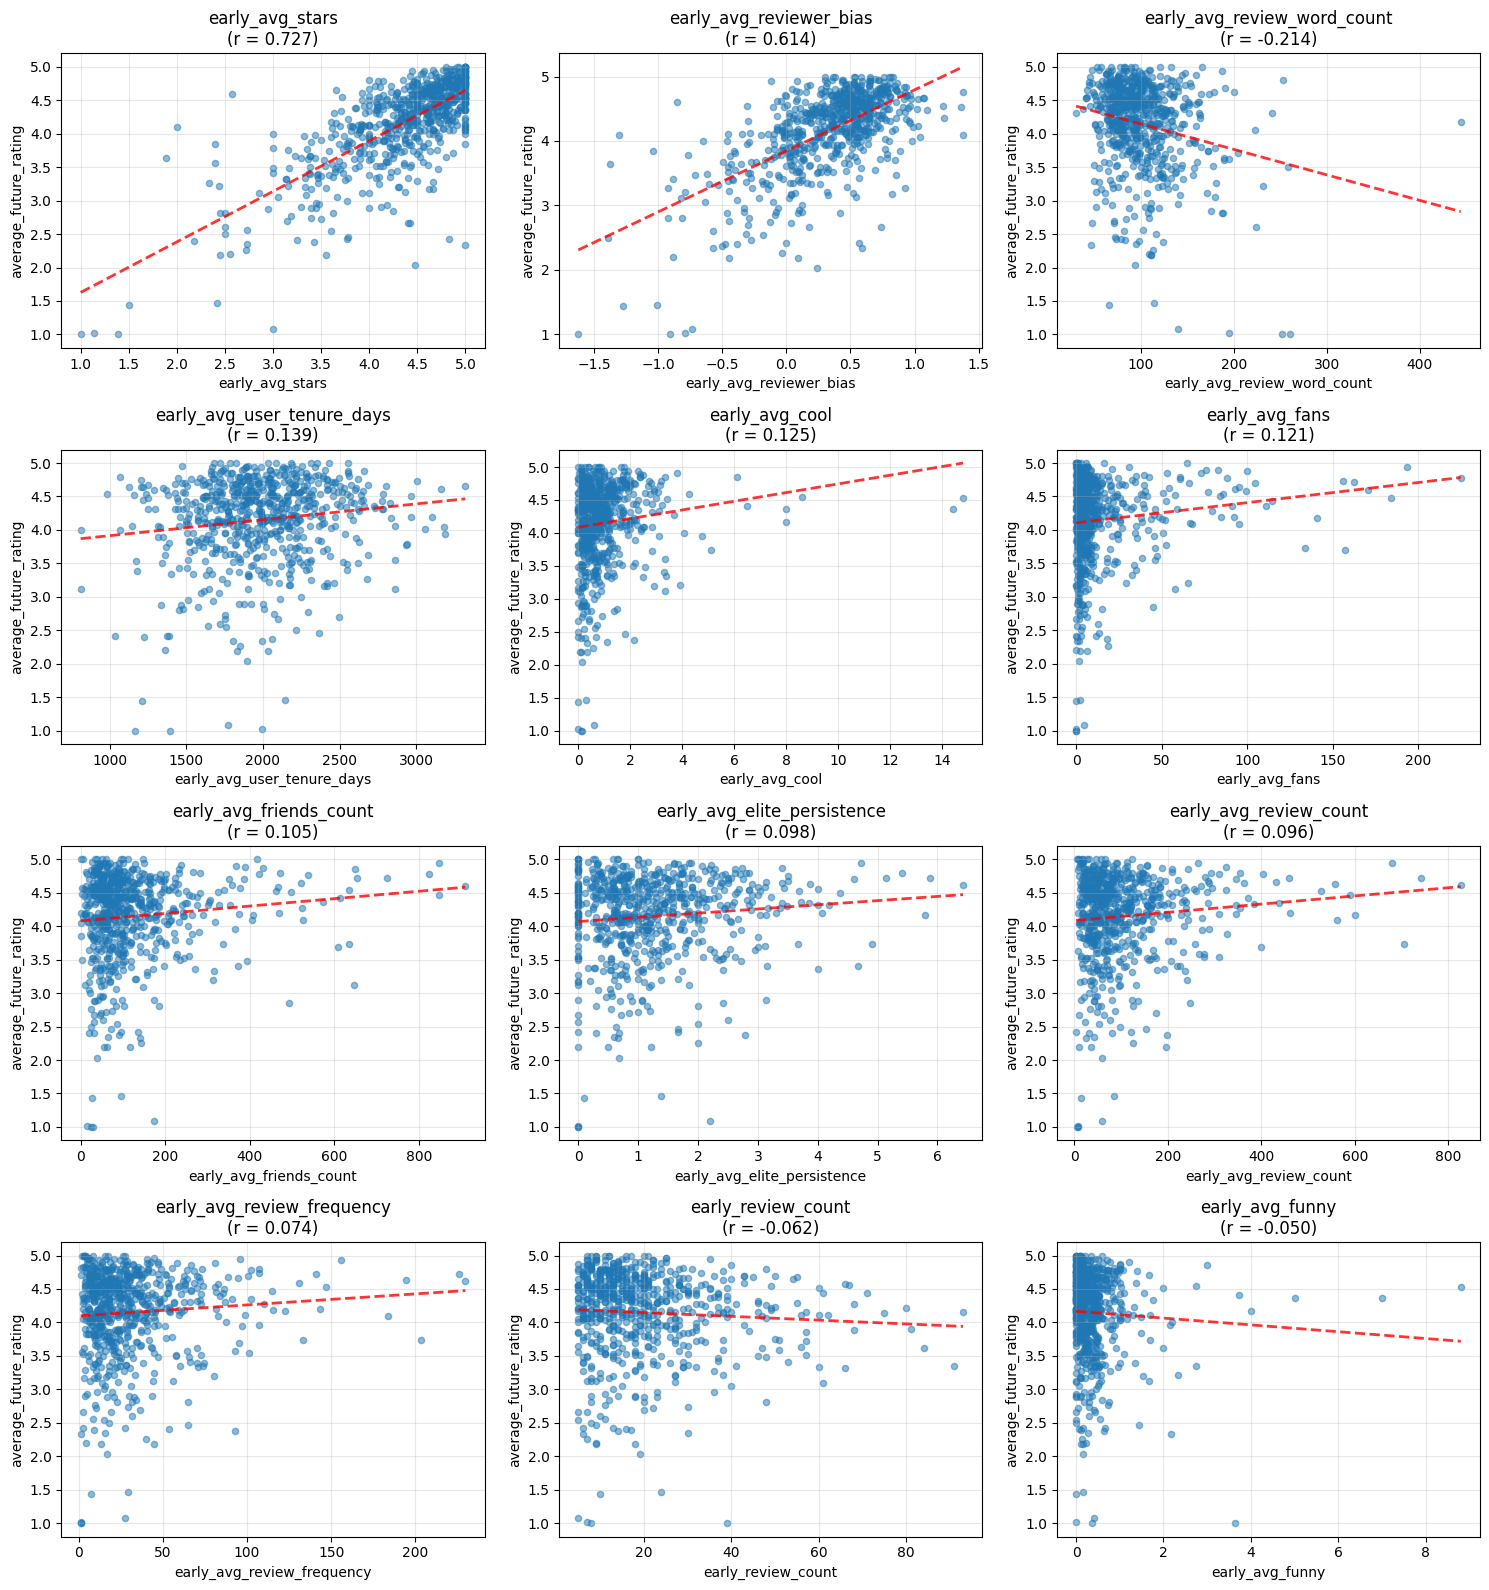

In [6]:
# Top Features vs Target Relationships
from scipy import stats

# Get top correlated features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if target_col in numeric_cols:
    corr_with_target = model_df[numeric_cols].corr()[target_col].drop(target_col)
    top_features = corr_with_target.abs().sort_values(ascending=False).head(12).index.tolist()
    
    # Create scatter plots for top features
    n_features = len(top_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for idx, feature in enumerate(top_features):
        ax = axes[idx]
        
        # Scatter plot
        ax.scatter(model_df[feature], model_df[target_col], alpha=0.5, s=20)
        
        # Add trend line
        z = np.polyfit(model_df[feature].dropna(), model_df[target_col].loc[model_df[feature].notna()], 1)
        p = np.poly1d(z)
        x_line = np.linspace(model_df[feature].min(), model_df[feature].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        # Calculate correlation
        corr_coef = corr_with_target[feature]
        
        ax.set_xlabel(feature)
        ax.set_ylabel(target_col)
        ax.set_title(f"{feature}\n(r = {corr_coef:.3f})")
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"{target_col} not in numeric columns; skipping feature vs target analysis.")
